### Figure 3
Same as LVK Coll paper on short-duration search for GW transients.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import *
import matplotlib.ticker
import sys
import pandas as pd
import scipy.stats as sstats

In [2]:
plt.rcParams.update(plt.rcParamsDefault)
size=20
params = {'legend.fontsize': 'large',
          'figure.figsize': (8,5),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.8,
          'ytick.labelsize': size*0.8,
          'legend.fontsize': size*0.8,
          'axes.titlepad': 7,
          'font.family': 'STIXGeneral',
          'font.weight': 'medium',
          'xtick.major.size': 10,
          'ytick.major.size': 10,
          'xtick.minor.size': 5,
          'ytick.minor.size': 5,
          'mathtext.fontset': 'stix',
          }
plt.rcParams.update(params)

In [3]:
colors = {"bayeswave": "#7469AF",
          "cwb": "#740B0F",
          "lib": "#809FFF"}
def lighten(color, amount=0.5):
    """
    Lightens the given color by multiplying (1-luminosity) by the given amount.
    Input can be matplotlib color string, hex string, or RGB tuple.

    See
    https://gist.github.com/ihincks/6a420b599f43fcd7dbd79d56798c4e5a

    Examples:
    >> lighten_color('g', 0.3)
    >> lighten_color('#F034A3', 0.6)
    >> lighten_color((.3,.55,.1), 0.5)
    """
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])



In [4]:
livetime =0.26057 #livetime foreground in years #95.11 days

In [5]:
y = np.logspace(np.log10(.001),np.log(200),num=10000) # "number of events" used for plotting expected results

# error bar stuff
fap1 = 0.682689
fap2 = 0.954499
fap3 = 0.997300

sig1=np.array(sstats.poisson.interval(fap1,y))
sig2=np.array(sstats.poisson.interval(fap2,y))
sig3=np.array(sstats.poisson.interval(fap3,y))

# from pnp comment, return values at half integers for clearer plotting
sig1[0] = sig1[0]-.5
sig2[0] = sig2[0]-.5
sig3[0] = sig3[0]-.5

sig1[1] = sig1[1]+.5
sig2[1] = sig2[1]+.5
sig3[1] = sig3[1]+.5

In [10]:
fg = np.genfromtxt('../Data/background/CumulativeNumberVsIFAR_nobbh_loudest_model_X_Test_F25.XGB_rthr0_HE_O3b_as3.txt',names=True)

#fg = np.concatenate((fg,fg_b))
ifars = fg['ifaryear'] # use the same data as what's in the placeholder plots
ifars = np.sort(ifars)[::-1]
N = livetime/ifars # number of events detected
expected_N = np.arange(1,len(N)+1,1) # y axis

fg_BBH = np.genfromtxt('../Data/background/CumulativeNumberVsIFAR_bbh_loudest_model_X_Test_F25.XGB_rthr0_HE_O3b_as3.txt',names=True)

ifars_BBH = fg_BBH['ifaryear']
ifars_BBH = np.sort(ifars_BBH)[::-1]
N_BBH = livetime/ifars_BBH
expected_N_BBH = np.arange(1,len(N_BBH)+1,1) # y axis

print(len(expected_N), len(expected_N_BBH))

971 7363


/tmp/ipykernel_1603/2477040130.py:13: RuntimeWarning: divide by zero encountered in divide
  N_BBH = livetime/ifars_BBH


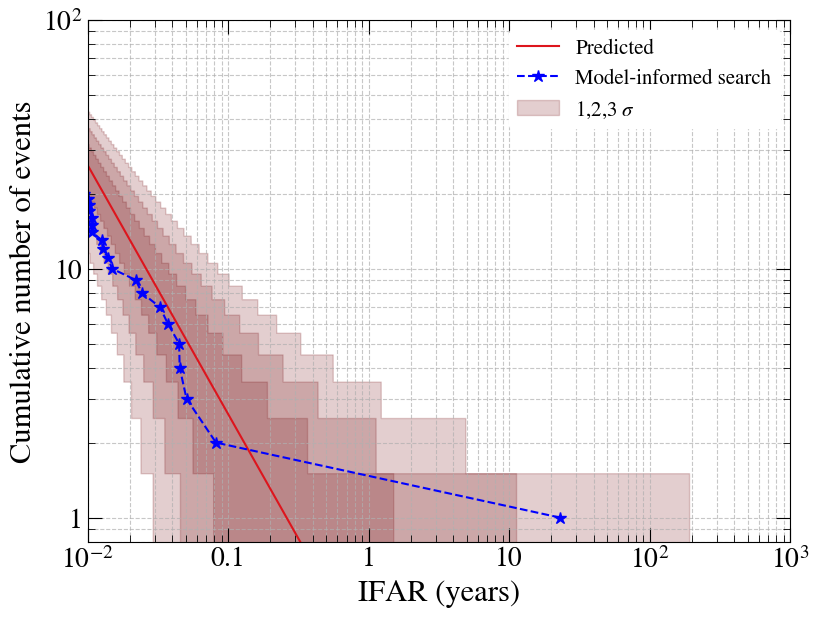

In [11]:
#f, ax = plt.subplots(1,1, figsize = o2plots.figsize) 

fig = plt.figure(figsize=(8,6))
ax = plt.gca()

plt.gcf().subplots_adjust(bottom=0.105)
plt.gcf().subplots_adjust(top=0.975)
plt.gcf().subplots_adjust(left=0.10)
plt.gcf().subplots_adjust(right=0.978)

ax.plot(livetime/y,y,label='Predicted', color=lighten(colors['cwb'], 0.7) ) # plot predicted iFAR vs recovered events
ax.plot(livetime/N_BBH,expected_N_BBH, '*--',label='Model-informed search', color='blue',markersize=9)
#ax.plot(livetime/N,expected_N, '.-',label='ML-enhanced search (CBC excluded)',color='blue')

ax.fill_between(livetime/y,sig1[0],sig1[1],alpha=0.2,label='1,2,3 $\sigma$',color=colors['cwb'])
ax.fill_between(livetime/y,sig2[0],sig2[1],alpha=0.2,color=colors['cwb'])
ax.fill_between(livetime/y,sig3[0],sig3[1],alpha=0.2,color=colors['cwb'])

ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(which='minor',alpha=0.7,linestyle='--')
ax.grid(which='major',alpha=0.7,linestyle='--')
ax.set_xlabel("IFAR (years)",fontsize=22)
ax.set_ylabel("Cumulative number of events",fontsize=22)
ax.set_ylim(0.8,100)
ax.set_xlim(10**-2,1*10**3)
ax.legend(fontsize=15, loc=1, frameon=True, framealpha=1, edgecolor='white')

ax.set_xticks([0.01,0.1,1,10,100,1000])
ax.set_yticks([1,10,100])
ax.set_xticklabels(['$10^{-2}$',0.1,'1','10','$10^2$','$10^3$'],fontsize=20)
ax.set_yticklabels(['1','10','$10^2$'],fontsize=20)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(axis="x",direction="in", which="both")
ax.tick_params(axis="y",direction="in", which="both")
#fig.savefig("zero_lag_HE_O3b_II.png")
plt.show()